In [1]:
%pip install nibabel
%pip install numpy
%pip install matplotlib
%pip install tqdm
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: C:\Users\ronen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: C:\Users\ronen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: C:\Users\ronen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: C:\Users\ronen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: C:\Users\ronen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Import Libraries

In [2]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
import pandas as pd

## Get Image Data

In [3]:
img_dir = "MRI_Seg_FBB10YC/"

In [4]:
img_paths = os.listdir(img_dir)

In [5]:
def pad_zeros(img: np.ndarray) -> np.ndarray:
    """
    Pad zeros to create 128 x 128 image.
    """
    first_dim, second_dim = img.shape

    col_pad = 128 - second_dim
    col_pad_side = col_pad // 2
    col_pad_left, col_pad_right = col_pad_side, col_pad_side
    if col_pad_side * 2 < col_pad:
        col_pad_right += 1
    img = np.concatenate(
        (
            np.zeros((first_dim, col_pad_left)),
            img,
            np.zeros((first_dim, col_pad_right))
        ), axis=1
    )

    row_pad = 128 - first_dim
    row_pad_side = row_pad // 2
    row_pad_top, row_pad_bottom = row_pad_side, row_pad_side
    if row_pad_side  * 2 < row_pad:
        row_pad_bottom += 1
    img = np.concatenate(
        (
            np.zeros((row_pad_top, 128)),
            img,
            np.zeros((row_pad_bottom, 128))
        )
    )

    return img

In [6]:
def get_Y() -> np.ndarray:
    """
    Concatenate 128 x 128 images side by side.
    """
    Y = None

    for i, img_path in enumerate(img_paths):
        img = nib.load(img_dir + img_path)
        img = img.get_fdata()
        img = np.mean(img, axis=2)  # 121 x 121 image.
        img = img[:, ~np.all(img == 0, axis=0)]  # Remove 0 columns.
        img = pad_zeros(img)
        if Y is not None:
            Y = np.concatenate((Y, img), axis=1)
        else:
            Y = img

    return Y

## Orthogonal Dictionary Learning

$\bm{Y}, \bm{X} \in \mathbb{R}^{n \times m}$, $\bm{A} \in O(n)$

Solve $\min_{\bm{q}} \frac{1}{m}\|\bm{q}^T\bm{Y}\|_1$ such that $\|\bm{q}\|_2 = 1$

$n \log(n)$ runs of subgradient method results with $\bm{A} = \{\bm{a}_1,\cdots,\bm{a}_n\}$

Solve $\min_{\bm{A}, \bm{X}} \frac{1}{2}\|\bm{Y} - \bm{A}\bm{X}\|_F^2 + \lambda \|\bm{X}\|_1$ such that $\bm{A} \in O(n)$

In [7]:
def SGM(Y: np.ndarray, niter: int=10000, eps: float=1e-5) -> tuple[np.ndarray, list[float]]:
    """
    Subgradient method.
    """
    objective_fun = lambda q: np.linalg.vector_norm(q.T @ Y, ord=1) /\
        Y.shape[1]
    projection = lambda q, z: z - q * (q.T @ z)
    gf = lambda q: Y @ np.sign(q.T @ Y).T / Y.shape[1]
    rgf = lambda q: projection(q, gf(q))
    rt = lambda z, u: (z + u) / np.linalg.vector_norm(z + u) 

    q = np.random.rand(Y.shape[0], 1)
    q /= np.linalg.vector_norm(q)
    out = np.empty(niter + 1)
    out[0] = objective_fun(q)
    for itr in range(niter):
        grad = rgf(q)
        eta = (itr + 1)**(-3 / 8) / (100 * np.sqrt(itr + 1))
        q = rt(q, -eta * grad)
        out[itr + 1] = objective_fun(q)
        if abs(out[itr + 1] - out[itr]) < eps:
            break
    return q, out[:itr + 2]

In [8]:
def ADM(Y: np.ndarray, A: np.ndarray, lam: float=0.02,
        niter: int=1000, eps: float=1e-5) -> tuple[np.ndarray, np.ndarray]:
    """
    Alternating Direction Method
    """
    objective_fun = lambda A, X:\
        0.5 * np.linalg.matrix_norm(Y - A @ X)**2 +\
            lam * np.linalg.matrix_norm(X, ord=1)

    out_prev = 1e4
    for itr in trange(niter):
        X = np.sign(A.T @ Y) * np.maximum(np.abs(A.T @ Y) - lam, 0)
        U, _, V = np.linalg.svd(Y @ X.T, full_matrices=False)
        A = U @ V
        out = objective_fun(A, X)
        if abs(out - out_prev) < eps:
            break
        out_prev = out
    return A, X

In [9]:
if not os.path.isdir("Plots"):
    os.mkdir("Plots")

 12%|█▎        | 125/1000 [00:02<00:14, 60.39it/s]


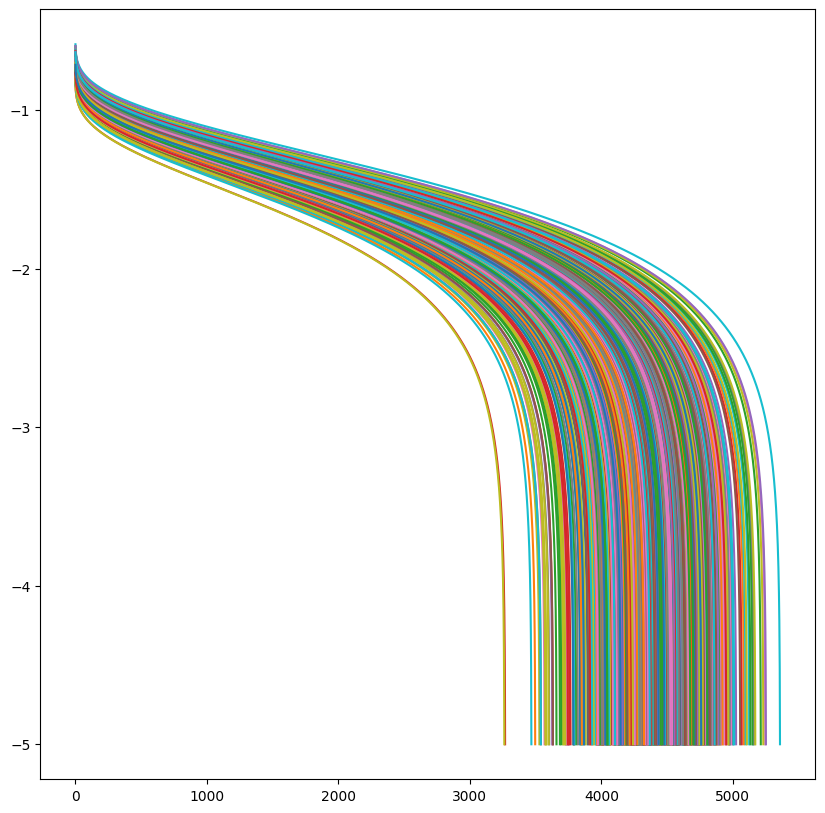

In [ ]:
A = None
Y = get_Y()

num_iterations = round(Y.shape[0] * np.log(Y.shape[0]))
plt.subplots(figsize=(10, 10))
for i in trange(num_iterations):
    q_i, out_i = SGM(Y)
    if A is None:
        A = q_i
    else:
        A = np.concatenate((A, q_i), axis=1)
    plt.plot(
        range(len(out_i) - 1),
        np.log10(np.array(out_i[:-1] - out_i[-1]))
    )
plt.savefig(
    "Plots/subgradient_convergence.jpg",
    dpi=500, bbox_inches="tight"
)

for i in trange(num_iterations - Y.shape[0]):
    corr = np.corrcoef(A, rowvar=False)
    col = np.unravel_index(np.argmax(np.triu(corr, 1)), corr.shape)[1]
    A = np.delete(A, col, axis=1)

A_1, X_1 = ADM(Y, A, 0.02)
A_2, X_2 = ADM(Y, A, 0.05)
A_3, X_3 = ADM(Y, A, 0.10)
A_4, X_4 = ADM(Y, A, 0.20)

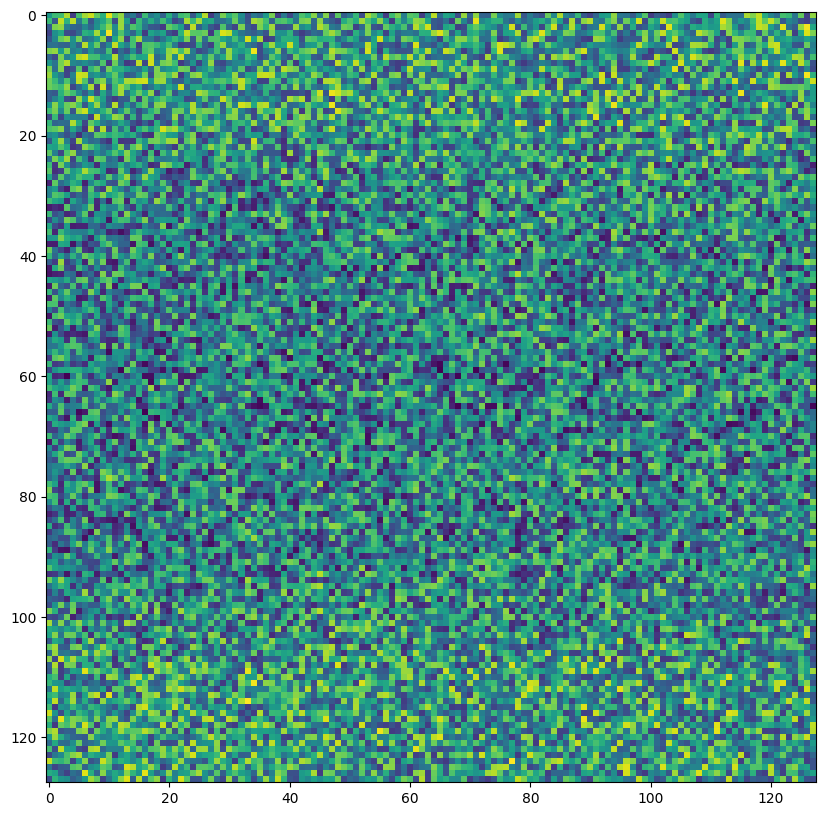

In [11]:
plt.subplots(figsize=(10, 10))
plt.imshow(A)
plt.savefig("Plots/original_A.jpg", dpi=500, bbox_inches="tight")
plt.show()

In [12]:
def calculate_sparsity(X_i: np.ndarray) -> tuple[float, int]:
    zeros = 128**2 - np.count_nonzero(X_i)

    # Remove 0 columns.
    zero_cols = np.all(X_i == 0, axis=0)
    X_i = X_i[:, ~zero_cols]

    sparsity = 0
    for i in range(X_i.shape[1]):
        col_vector = X_i[:, [[i]]]
        l1 = np.linalg.vector_norm(col_vector, ord=1)
        l2 = np.linalg.vector_norm(col_vector, ord=2)
        sparsity += (l1 / l2)
    sparsity /= X_i.shape[1]

    return sparsity, zeros

In [ ]:
def plot_mri(Y: np.ndarray, A: list[np.ndarray], X: list[np.ndarray],
             lam: list[float], i: int) ->\
        tuple[str, list[int], int, list[float], list[float]]:
    Y_i = Y[:, i * 128:(i + 1) * 128]

    zeros_X_list = []
    zeros_Y = 128**2 - np.count_nonzero(Y_i)
    sparsity_list = []
    error_list = []

    _, ax = plt.subplots(1, 1 + len(A), figsize=(20, 20))
    ax[0].imshow(Y_i.T)
    ax[0].set_title("Original")

    print("Image:", img_paths[i])
    for j, (A_ij, X_ij, lam_j) in enumerate(zip(A, X, lam)):
        X_i = X_ij[:, i * 128:(i + 1) * 128]
        Y_tilde_i = A_ij @ X_i

        error = np.linalg.matrix_norm(Y_i - Y_tilde_i, ord=2)
        sparsity, zeros_X = calculate_sparsity(X_i)
        
        zeros_X_list.append(zeros_X)
        sparsity_list.append(sparsity)
        error_list.append(error)
        
        print()
        print("Lambda:", lam_j)
        print("Number of Zeros X:", zeros_X)
        print("Number of Zeros Y:", zeros_Y)
        print("Sparsity of X:", sparsity)
        print("Error of AX:", error)

        ax[j + 1].imshow(Y_tilde_i.T)
        ax[j + 1].set_title("Reconstructed lam=" + str(lam_j))
    
    plt.savefig(
        "Plots/" + img_paths[i].rstrip(".nii") + "_original_reconstructed.jpg",
        dpi=500, bbox_inches="tight"
    )
    plt.show()

    return img_paths[i], zeros_X_list, zeros_Y, sparsity_list, error_list

In [14]:
if not os.path.isdir("Tables"):
    os.mkdir("Tables")

Image: mwc1MR_1001_2_20160701130924.nii

Lambda: 0.01
Number of Zeros X: 12408
Number of Zeros Y: 7295
Sparsity of X: 1.90767625728578
Error of AX: 4.4791055615483666e-05

Lambda: 0.02
Number of Zeros X: 13860
Number of Zeros Y: 7295
Sparsity of X: 1.8577452613928067
Error of AX: 7.390645328273698e-05

Lambda: 0.05
Number of Zeros X: 15416
Number of Zeros Y: 7295
Sparsity of X: 1.4822861392254394
Error of AX: 0.00013266010128594154

Lambda: 0.1
Number of Zeros X: 15911
Number of Zeros Y: 7295
Sparsity of X: 1.3457791706968696
Error of AX: 0.00019186629700119884


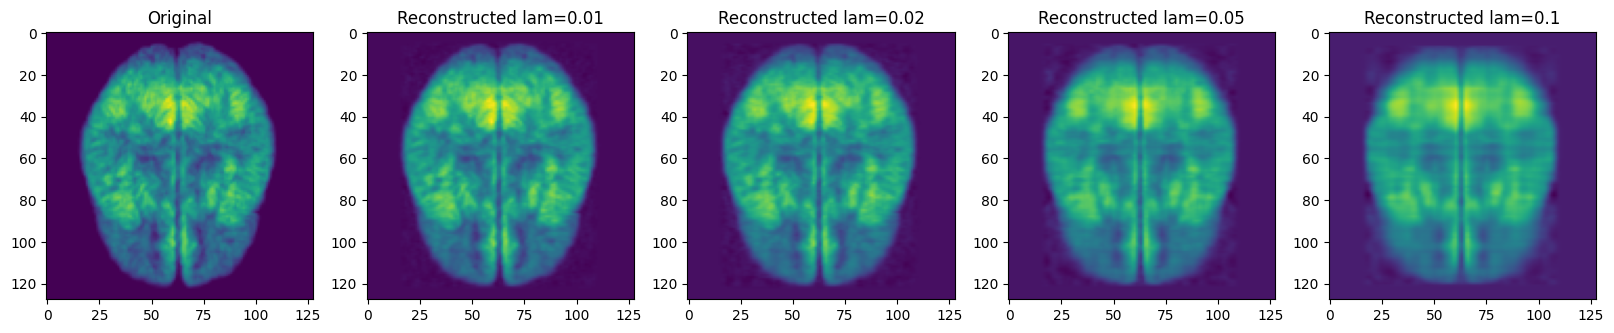

Image: mwc1MR_1002_2_20160715122634.nii

Lambda: 0.01
Number of Zeros X: 12533
Number of Zeros Y: 7223
Sparsity of X: 1.9029515515080118
Error of AX: 4.396788077385115e-05

Lambda: 0.02
Number of Zeros X: 13955
Number of Zeros Y: 7223
Sparsity of X: 1.8379948766815828
Error of AX: 7.207267621251174e-05

Lambda: 0.05
Number of Zeros X: 15553
Number of Zeros Y: 7223
Sparsity of X: 1.4646163922099469
Error of AX: 0.00012623374150021326

Lambda: 0.1
Number of Zeros X: 15948
Number of Zeros Y: 7223
Sparsity of X: 1.319186292969442
Error of AX: 0.00018410161148158479


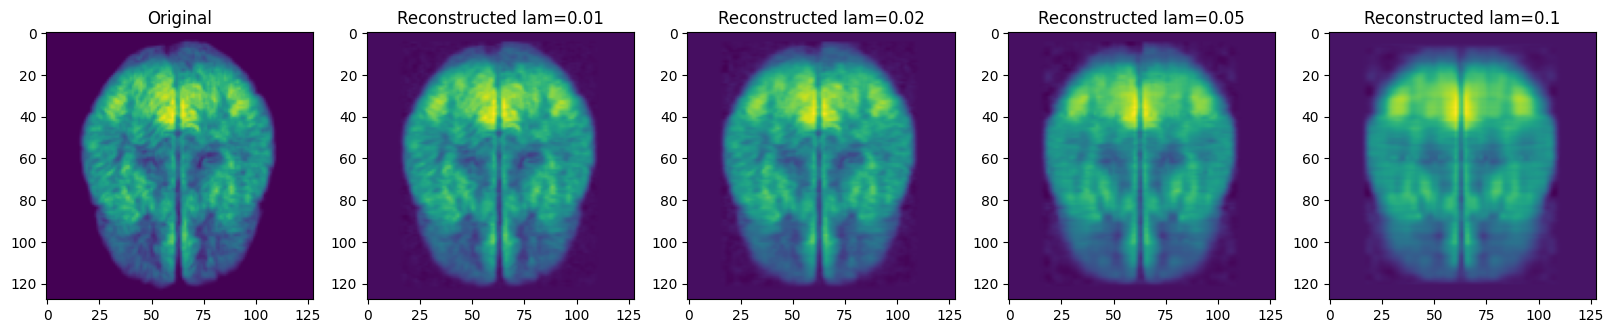

Image: mwc1MR_1003_5_20160914100618.nii

Lambda: 0.01
Number of Zeros X: 12251
Number of Zeros Y: 7225
Sparsity of X: 1.924972478019804
Error of AX: 4.547913259643366e-05

Lambda: 0.02
Number of Zeros X: 13782
Number of Zeros Y: 7225
Sparsity of X: 1.8778425970965091
Error of AX: 7.46084952478728e-05

Lambda: 0.05
Number of Zeros X: 15398
Number of Zeros Y: 7225
Sparsity of X: 1.4845837027388546
Error of AX: 0.0001344452850536514

Lambda: 0.1
Number of Zeros X: 15905
Number of Zeros Y: 7225
Sparsity of X: 1.3479022290222435
Error of AX: 0.00019317701234324386


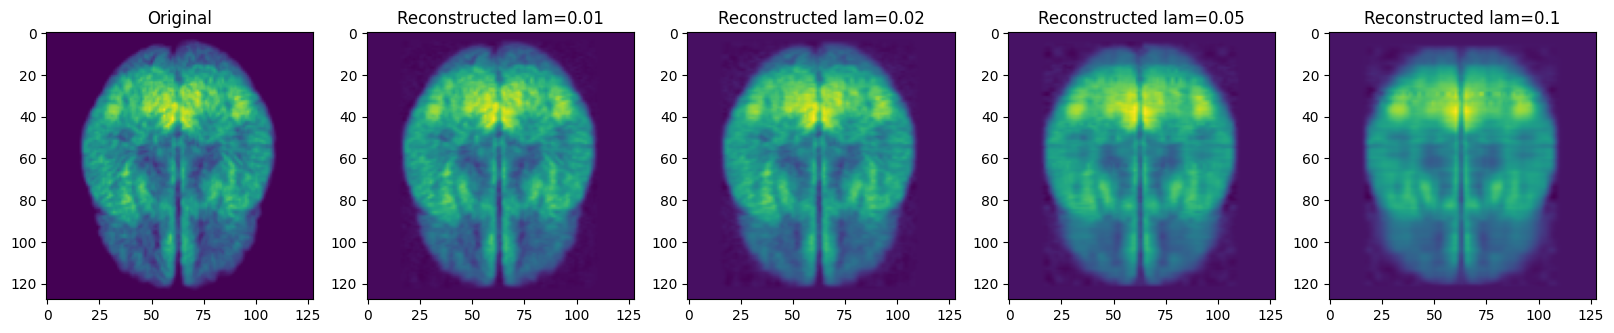

Image: mwc1MR_1004_2_20160805130611.nii

Lambda: 0.01
Number of Zeros X: 12582
Number of Zeros Y: 7342
Sparsity of X: 1.9085040083869078
Error of AX: 4.392327695919778e-05

Lambda: 0.02
Number of Zeros X: 13971
Number of Zeros Y: 7342
Sparsity of X: 1.8379759140131027
Error of AX: 7.200406679835435e-05

Lambda: 0.05
Number of Zeros X: 15526
Number of Zeros Y: 7342
Sparsity of X: 1.4574786763971044
Error of AX: 0.0001267076579463487

Lambda: 0.1
Number of Zeros X: 15961
Number of Zeros Y: 7342
Sparsity of X: 1.3207295277459967
Error of AX: 0.00018062259394828513


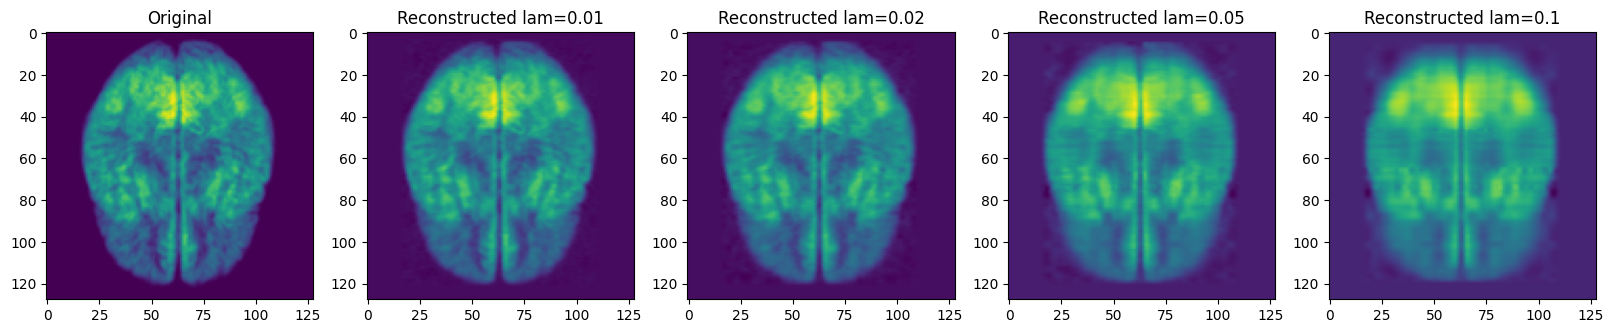

Image: mwc1MR_1005_2_20160722123224.nii

Lambda: 0.01
Number of Zeros X: 12249
Number of Zeros Y: 7143
Sparsity of X: 1.959508015918942
Error of AX: 4.5179733467769934e-05

Lambda: 0.02
Number of Zeros X: 13753
Number of Zeros Y: 7143
Sparsity of X: 1.901276478184171
Error of AX: 7.491325750448471e-05

Lambda: 0.05
Number of Zeros X: 15319
Number of Zeros Y: 7143
Sparsity of X: 1.5198625997835618
Error of AX: 0.00013587464284578346

Lambda: 0.1
Number of Zeros X: 15892
Number of Zeros Y: 7143
Sparsity of X: 1.3599015344028422
Error of AX: 0.00019631604829381378


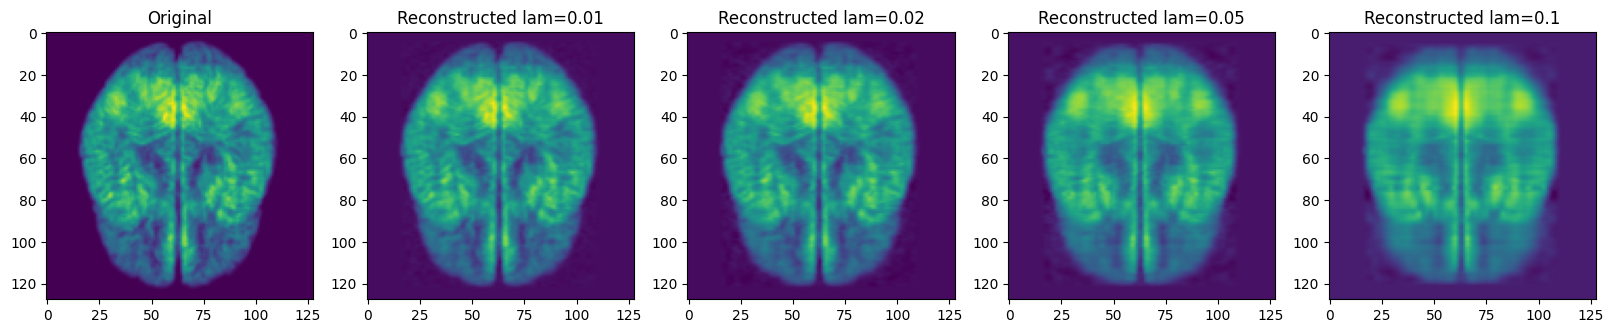

Image: mwc1MR_1007_2_20160719124145.nii

Lambda: 0.01
Number of Zeros X: 12605
Number of Zeros Y: 7191
Sparsity of X: 1.8810731826723792
Error of AX: 4.367347190906482e-05

Lambda: 0.02
Number of Zeros X: 14025
Number of Zeros Y: 7191
Sparsity of X: 1.815972910138321
Error of AX: 7.136963852232833e-05

Lambda: 0.05
Number of Zeros X: 15524
Number of Zeros Y: 7191
Sparsity of X: 1.451818440014202
Error of AX: 0.00012554575786875467

Lambda: 0.1
Number of Zeros X: 15961
Number of Zeros Y: 7191
Sparsity of X: 1.3128825501582255
Error of AX: 0.00017992611529467172


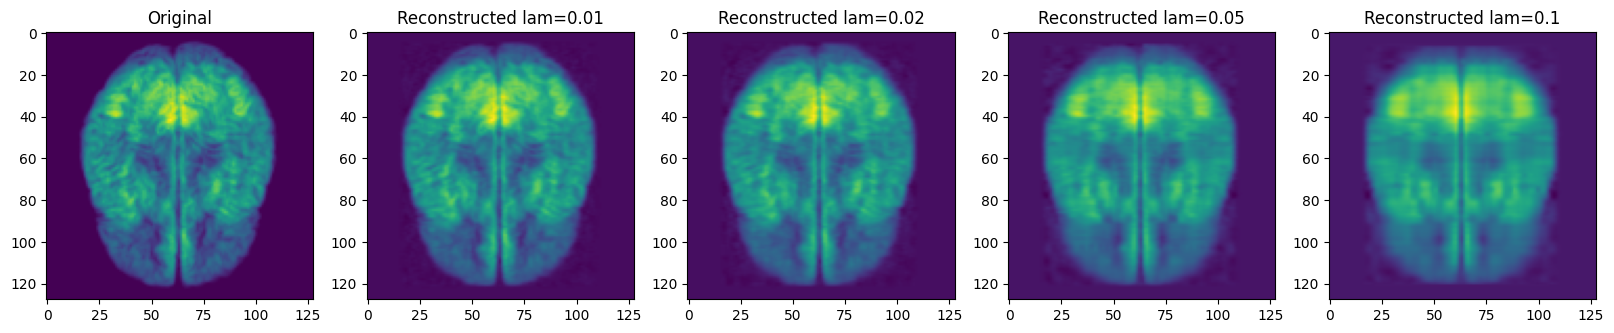

Image: mwc1MR_1011_2_20160823124322.nii

Lambda: 0.01
Number of Zeros X: 12310
Number of Zeros Y: 7070
Sparsity of X: 1.8781427364543555
Error of AX: 4.4947508712005614e-05

Lambda: 0.02
Number of Zeros X: 13794
Number of Zeros Y: 7070
Sparsity of X: 1.8625812486243425
Error of AX: 7.402251935420597e-05

Lambda: 0.05
Number of Zeros X: 15409
Number of Zeros Y: 7070
Sparsity of X: 1.488338607662963
Error of AX: 0.00013295983989643862

Lambda: 0.1
Number of Zeros X: 15893
Number of Zeros Y: 7070
Sparsity of X: 1.3548207058244495
Error of AX: 0.00019497898063650053


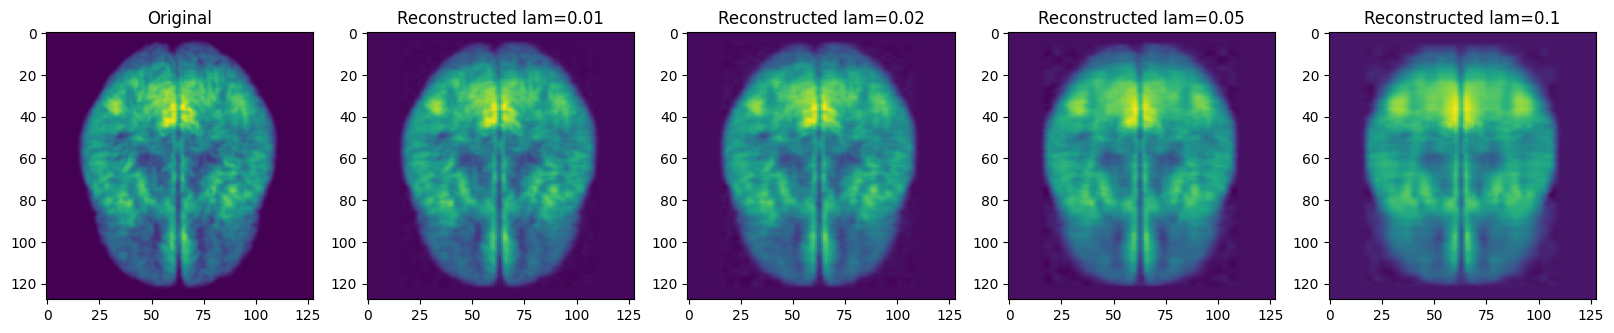

Image: mwc1MR_1012_2_20160722115010.nii

Lambda: 0.01
Number of Zeros X: 12351
Number of Zeros Y: 7333
Sparsity of X: 1.946659323683319
Error of AX: 4.470791523129994e-05

Lambda: 0.02
Number of Zeros X: 13724
Number of Zeros Y: 7333
Sparsity of X: 1.8812615281165987
Error of AX: 7.463321944970293e-05

Lambda: 0.05
Number of Zeros X: 15373
Number of Zeros Y: 7333
Sparsity of X: 1.5084189274251045
Error of AX: 0.00013397515237709837

Lambda: 0.1
Number of Zeros X: 15885
Number of Zeros Y: 7333
Sparsity of X: 1.3643051150862155
Error of AX: 0.00019508729819210077


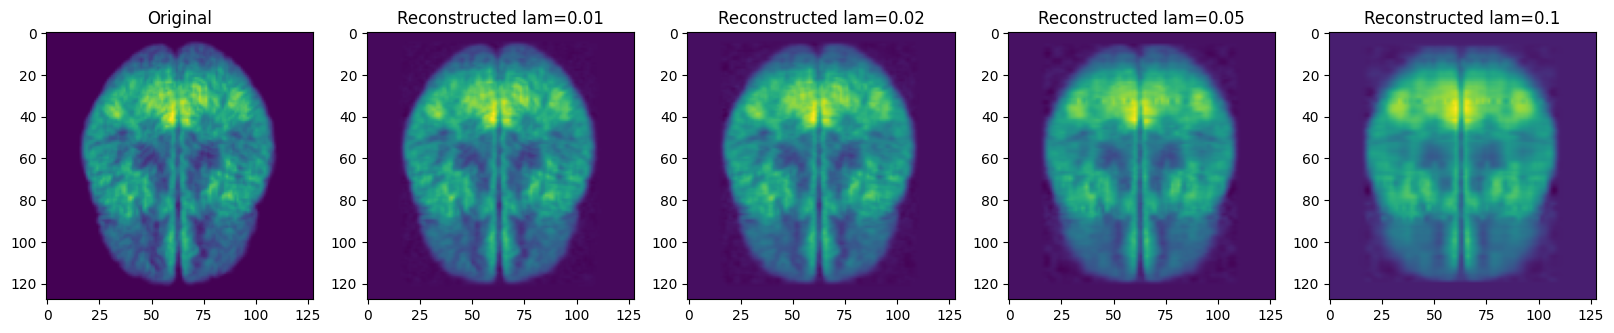

Image: mwc1MR_1017_2_20160902140329.nii

Lambda: 0.01
Number of Zeros X: 12211
Number of Zeros Y: 7275
Sparsity of X: 1.9582837261656592
Error of AX: 4.5296540083941384e-05

Lambda: 0.02
Number of Zeros X: 13692
Number of Zeros Y: 7275
Sparsity of X: 1.8983885916362901
Error of AX: 7.534892378840753e-05

Lambda: 0.05
Number of Zeros X: 15342
Number of Zeros Y: 7275
Sparsity of X: 1.5225124946553785
Error of AX: 0.00013413113655788835

Lambda: 0.1
Number of Zeros X: 15865
Number of Zeros Y: 7275
Sparsity of X: 1.366402995505596
Error of AX: 0.000197969453485986


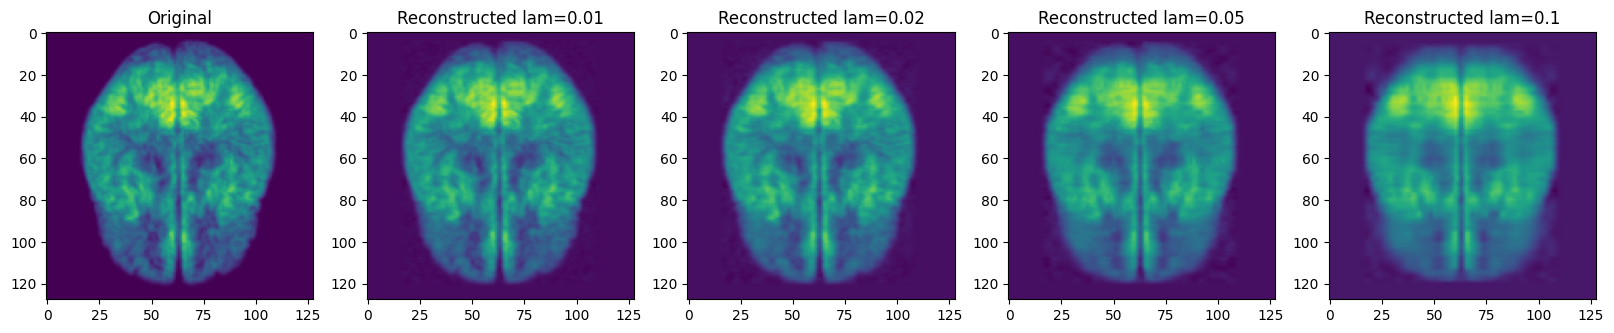

Image: mwc1MR_1021_2_20160916100329.nii

Lambda: 0.01
Number of Zeros X: 12320
Number of Zeros Y: 7017
Sparsity of X: 1.923021925984379
Error of AX: 4.498000906635583e-05

Lambda: 0.02
Number of Zeros X: 13754
Number of Zeros Y: 7017
Sparsity of X: 1.871534333927947
Error of AX: 7.487644214968924e-05

Lambda: 0.05
Number of Zeros X: 15376
Number of Zeros Y: 7017
Sparsity of X: 1.4939704999643835
Error of AX: 0.00013295809214756692

Lambda: 0.1
Number of Zeros X: 15872
Number of Zeros Y: 7017
Sparsity of X: 1.349978580614948
Error of AX: 0.00019629049204190487


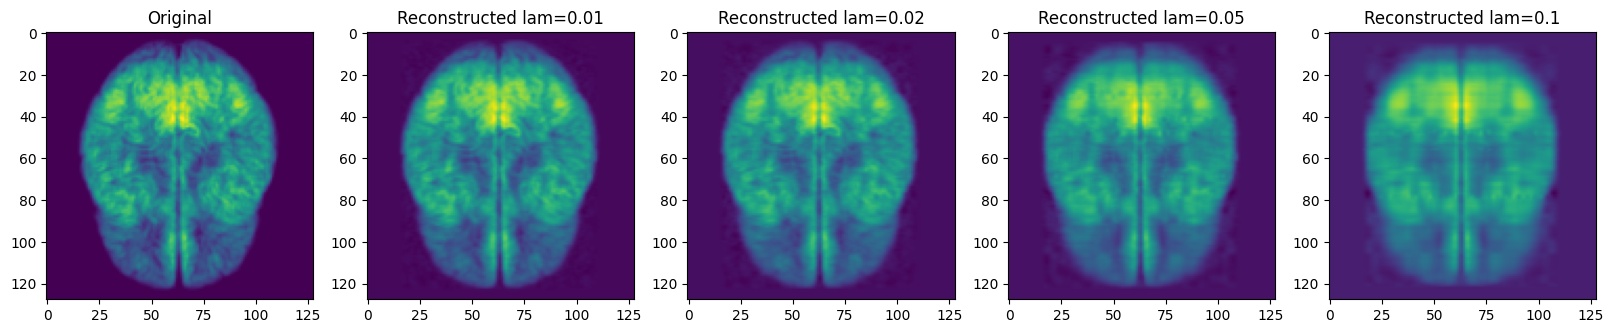

In [ ]:
img_strs, zero_X_strs, zero_Y, zero_Y_strs, sparsity_strs, error_strs =\
    [], [], [], [], [], []
lam = [0.02, 0.05, 0.10, 0.20]

for i in range(10):
    img_str, zeros_X_list, zeros_Y, sparsity_list, error_list =\
        plot_mri(Y, [A_1, A_2, A_3, A_4], [X_1, X_2, X_3, X_4], lam, i)
    img_strs.extend([img_str] * 4)
    zero_X_strs.extend(zeros_X_list)
    zero_Y.extend([zeros_Y] * 4)
    zero_Y_strs.append(zeros_Y)
    sparsity_strs.extend(sparsity_list)
    error_strs.extend(error_list)

In [16]:
reconstructed_image_avg = pd.DataFrame(
    {
        "Lambda": lam,
        "Average Number of Zeros X": [
            " ".join(
                [
                    str(np.mean([zero_X_strs[i] for i in range(0, len(zero_X_strs), 4)])),
                    "+-",
                    str(np.std([zero_X_strs[i] for i in range(0, len(zero_X_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([zero_X_strs[i] for i in range(1, len(zero_X_strs), 4)])),
                    "+-",
                    str(np.std([zero_X_strs[i] for i in range(1, len(zero_X_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([zero_X_strs[i] for i in range(2, len(zero_X_strs), 4)])),
                    "+-",
                    str(np.std([zero_X_strs[i] for i in range(2, len(zero_X_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([zero_X_strs[i] for i in range(3, len(zero_X_strs), 4)])),
                    "+-",
                    str(np.std([zero_X_strs[i] for i in range(3, len(zero_X_strs), 4)]))
                ]
            )
        ],
        "Average Number of Zeros Y": [
            " ".join(
                [
                    str(np.mean(zero_Y_strs)),
                    "+-",
                    str(np.std(zero_Y_strs))
                ]
            ),
            " ".join(
                [
                    str(np.mean(zero_Y_strs)),
                    "+-",
                    str(np.std(zero_Y_strs))
                ]
            ),
            " ".join(
                [
                    str(np.mean(zero_Y_strs)),
                    "+-",
                    str(np.std(zero_Y_strs))
                ]
            ),
            " ".join(
                [
                    str(np.mean(zero_Y_strs)),
                    "+-",
                    str(np.std(zero_Y_strs))
                ]
            )
        ],
        "Average Sparsity": [
            " ".join(
                [
                    str(np.mean([sparsity_strs[i] for i in range(0, len(sparsity_strs), 4)])),
                    "+-",
                    str(np.std([sparsity_strs[i] for i in range(0, len(sparsity_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([sparsity_strs[i] for i in range(1, len(sparsity_strs), 4)])),
                    "+-",
                    str(np.std([sparsity_strs[i] for i in range(1, len(sparsity_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([sparsity_strs[i] for i in range(2, len(sparsity_strs), 4)])),
                    "+-",
                    str(np.std([sparsity_strs[i] for i in range(2, len(sparsity_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([sparsity_strs[i] for i in range(3, len(sparsity_strs), 4)])),
                    "+-",
                    str(np.std([sparsity_strs[i] for i in range(3, len(sparsity_strs), 4)]))
                ]
            )
        ],
        "Average Error": [
            " ".join(
                [
                    str(np.mean([error_strs[i] for i in range(0, len(error_strs), 4)])),
                    "+-",
                    str(np.std([error_strs[i] for i in range(0, len(error_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([error_strs[i] for i in range(1, len(error_strs), 4)])),
                    "+-",
                    str(np.std([error_strs[i] for i in range(1, len(error_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([error_strs[i] for i in range(2, len(error_strs), 4)])),
                    "+-",
                    str(np.std([error_strs[i] for i in range(2, len(error_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([error_strs[i] for i in range(3, len(error_strs), 4)])),
                    "+-",
                    str(np.std([error_strs[i] for i in range(3, len(error_strs), 4)]))
                ]
            )
        ]
    }
)

reconstructed_image_avg.to_csv("Tables/reconstructed_image_avg.csv", index=None)
reconstructed_image_avg

,Lambda,Average Number of Zeros X,Average Number of Zeros Y,Average Sparsity,Average Error
0,0.01,12382.0 +- 136.85247531557476,7211.4 +- 102.99339784665811,1.919079320607954 +- 0.027576506833788223,4.469465244154037e-05 +- 5.944613100534522e-07
1,0.02,13831.0 +- 109.54725007958895,7211.4 +- 102.99339784665811,1.8642573739811674 +- 0.026113307226903377,7.377556923102946e-05 +- 1.3533555732265353e-06
2,0.05,15423.6 +- 77.88607064167508,7211.4 +- 102.99339784665811,1.4873886480076939 +- 0.02342448087913791,0.00013154914074796855 +- 3.641336778593421e-06
3,0.10,15909.3 +- 33.72550963291734,7211.4 +- 102.99339784665811,1.3441888702026827 +- 0.018610342672062147,0.00019103359027192903 +- 6.4865172779470205e-06


In [17]:
reconstructed_image_data = pd.DataFrame(
    {
        "Image": img_strs, "Number of Zeros X": zero_X_strs,
        "Number of Zeros Y": zero_Y, "Sparsity": sparsity_strs,
        "Error": error_strs, "Lambda": lam * 10
    }
)
reconstructed_image_data.to_csv('Tables/reconstructed_image_data.csv', index=None)